# Chapter 9 — Radiative Transfer with Scattering

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapters 5–8 built absorption and scattering at every depth and
wavelength. Those arrays still do not tell us what leaves the star.
To see why, imagine two columns with the same temperature profile
and the same total extinction
\(\chi_\nu=\kappa_\nu+\sigma_\nu\). In one, true absorption
dominates: removed radiation is replaced efficiently by local
thermal emission. In the other, scattering dominates: a removed
ray is replaced mainly by radiation arriving from elsewhere.
Both columns have the same optical depth, yet their emergent
radiation need not agree.

This chapter asks:

> **Given depth-dependent absorption, thermal emission, and
> scattering, what total and continuum flux actually leave the
> stellar surface?**

We assume a static, one-dimensional, plane-parallel atmosphere.
Material populations and thermal emissivity remain in LTE. Standard
line opacity is thermal absorption; standard synthesis supplies
`line_scattering = 0`. We do not solve NLTE populations, partial
frequency redistribution, polarization, winds, time dependence, or
an instrument model.

The exact synthesis boundary reads depth-major arrays
`(D, W)` in cm\(^2\) g\(^{-1}\), plus `planck_source (D,W)` and
increasing `column_mass (D,)` in g cm\(^{-2}\). It returns
device-resident total and continuum \(H_\nu\), and their ratio,
each with shape `(W,)`. The atmosphere boundary instead consumes
one CPU float64 frequency column and returns depth-dependent
\(J_\nu\), \(H_\nu\), \(J_\nu-S_\nu\), and a surface second moment.

Before calculation we predict three outcomes:

1. with no scattering, the complete source is local and thermal;
2. with no line opacity, total and continuum transfer agree;
3. fixed extinction does not fix emergent \(H_\nu\) if the
   absorption/scattering division changes.

> **Movement I — From a known source to escaping radiation.**
> We first make the missing source information visible, then build
> rays and angular moments before introducing the fixed operator.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from book.chapter09_runtime import (
    ATMOSPHERE_TRANSFER_TABLES_SHA256,
    SYNTHESIS_TRANSFER_TABLES_SHA256,
    _configure_staged_source,
    atmosphere_moment_checkpoint,
    atmosphere_parallel_checkpoint,
    contribution_checkpoint,
    equal_extinction_checkpoint,
    flux_conversion_checkpoint,
    hand_sweep_checkpoint,
    optical_depth_checkpoint,
    prepared_window_checkpoint,
    remap_checkpoint,
    saturated_route_checkpoint,
    source_sweep_checkpoint,
    synthesis_transfer_tables,
    transfer_table_checkpoint,
)
_configure_staged_source()

from book.chapter06_runtime import continuous_voigt_h
from book.chapter09_teaching import (
    angular_moments,
    formal_surface_intensity,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel
from payne_zero_synthesis.radiative_transfer import (
    FLOAT32_POSITIVE_FLOOR,
    _solve_flux_rows,
    source_and_alpha,
)


## 9.1 Extinction is not a complete source function

At one frequency, separate the opacity per mass into continuum and
line absorption \(\kappa_{\nu,\mathrm c}\),
\(\kappa_{\nu,\mathrm l}\), and continuum and line scattering
\(\sigma_{\nu,\mathrm c}\), \(\sigma_{\nu,\mathrm l}\):

\[
\chi_\nu=\kappa_{\nu,\mathrm c}+\kappa_{\nu,\mathrm l}
         +\sigma_{\nu,\mathrm c}+\sigma_{\nu,\mathrm l},
\qquad
\alpha_\nu=
\frac{\sigma_{\nu,\mathrm c}+\sigma_{\nu,\mathrm l}}{\chi_\nu}.
\]

Here \(\alpha_\nu\) is the **scattering fraction**. It is not the
thermal fraction used in some texts; that complement is
\(1-\alpha_\nu\). The absorption-weighted thermal source is

\[
S_{\nu,\mathrm{th}}=
\frac{\kappa_{\nu,\mathrm c}S_{\nu,\mathrm c}
      +\kappa_{\nu,\mathrm l}S_{\nu,\mathrm l}}
     {\kappa_{\nu,\mathrm c}+\kappa_{\nu,\mathrm l}} .
\]

We now construct the opening columns. Row 0 is absorption-rich and
row 1 is scattering-rich. Their extinction is identical at every
depth.


In [3]:
equal = equal_extinction_checkpoint()

assert np.array_equal(equal.extinction[0], equal.extinction[1])
assert not np.array_equal(
    equal.scattering_fraction[0],
    equal.scattering_fraction[1],
)
print("same extinction:", np.array_equal(
    equal.extinction[0], equal.extinction[1]
))
print(
    "surface scattering fractions:",
    equal.scattering_fraction[:, 0],
)
print(
    "emergent H_nu:",
    equal.eddington_flux_per_frequency,
)


same extinction: True
surface scattering fractions: [0.1 0.9]
emergent H_nu: [0.39516978 0.22765586]


The equal extinction gives equal optical-depth geometry. The
different \(H_\nu\) values prove that geometry alone is
insufficient: we must say what replaces radiation removed from a
ray.

The exact `source_and_alpha(...)` function floors
`total_extinction` at \(10^{-38}\), clips
`scattering_fraction` into \([0,1]\), and uses
`continuum_source` as a harmless thermal-source fallback if true
absorption vanishes. The complete source later multiplies that
fallback by \(1-\alpha_\nu\), so a purely scattering point does not
secretly create thermal photons.


In [4]:
shape = (1, 3)
continuum_absorption = torch.zeros(shape, dtype=torch.float64)
continuum_scattering = torch.tensor(
    [[0.0, 2.0, 1.0]],
    dtype=torch.float64,
)
continuum_source = torch.tensor(
    [[0.4, 0.8, 1.2]],
    dtype=torch.float64,
)
zeros = torch.zeros_like(continuum_absorption)

extinction, scattering_fraction, thermal_source = source_and_alpha(
    continuum_absorption,
    continuum_source,
    zeros,
    continuum_source,
    continuum_scattering,
    zeros,
)
assert extinction.min() == FLOAT32_POSITIVE_FLOOR
assert torch.all((scattering_fraction >= 0) & (scattering_fraction <= 1))
assert torch.equal(thermal_source, continuum_source)
print("extinction:", extinction.numpy())
print("scattering fraction:", scattering_fraction.numpy())
print("fallback thermal source:", thermal_source.numpy())


extinction: [[1.e-38 2.e+00 1.e+00]]
scattering fraction: [[0. 1. 1.]]
fallback thermal source: [[0.4 0.8 1.2]]


## 9.2 Scattering makes the source function nonlocal

Those two pieces now combine. A photon removed from the beam is
either absorbed — its energy thermalized into the gas, to be
re-emitted according to the local temperature — or scattered, in
which case it is merely redirected and survives. Weighting the two
outcomes by their shares of the extinction gives the full source
function

\[
S_\nu=(1-\alpha_\nu)\,S_{\nu,\mathrm{th}}
      +\alpha_\nu J_\nu .
\]

The second term is what makes radiative transfer with scattering
hard. \(J_\nu\) is the mean intensity *at that depth*, and the mean
intensity is itself the result of transfer through the whole
atmosphere. The source function at one point therefore depends on
the source function everywhere else. There is no marching solution;
§9.7 has to iterate for exactly this reason.

The quantity \(1-\alpha_\nu\) — the absorption share, conventionally
called the photon destruction probability — controls how strongly
that coupling bites. Follow one photon: at each interaction it is
destroyed with probability \(1-\alpha_\nu\), so it survives roughly
\(1/(1-\alpha_\nu)\) interactions before thermalizing. A random walk
of \(N\) steps covers about \(\sqrt N\) mean free paths, so the
photon wanders

\[
\tau_{\rm th}\sim\frac{1}{\sqrt{1-\alpha_\nu}}
\]

optical depths from where its energy entered the radiation field.
This is the **thermalization depth**, and it is much deeper than one
mean free path whenever scattering dominates.

The consequence is visible at the surface. Photons escaping from
\(\tau_\nu\approx1\) in a scattering-dominated layer last touched
the thermal pool far deeper and much further from equilibrium with
the local gas, so the emergent source function falls below the local
thermal value — for a semi-infinite atmosphere with constant
\(S_{\rm th}\) it approaches
\(\sqrt{1-\alpha_\nu}\,S_{\rm th}\). A scattering-dominated line is
therefore darker than pure absorption would predict, and the surface
is the hardest place in the atmosphere to get right. That is the
physical reason §9.11 needs a separate diffusion route when the
surface saturates.

## 9.3 Optical depth belongs to one frequency

Column mass \(m\) increases inward. Extinction per mass turns its
interval \(dm\) into dimensionless optical depth:

\[
d\tau_\nu=\chi_\nu\,dm,\qquad
\tau_\nu(m)=\chi_\nu(m_0)m_0+
  \int_{m_0}^{m}\chi_\nu(m')\,dm'.
\]

Chapter 2 already derived the parabolic interval integral and the
ordered prefix; here we use it. The surface seed has no hidden
factor of one half. We compare the least line-affected wavelength
in the compact Chapter 5–8 window with its strongest line center.


In [5]:
optical = optical_depth_checkpoint()

assert optical.optical_depth.shape == (2, optical.column_mass.size)
assert np.all(np.diff(optical.optical_depth, axis=1) >= 0.0)
expected_surface = optical.extinction[:, 0] * optical.column_mass[0]
np.testing.assert_allclose(
    optical.optical_depth[:, 0],
    expected_surface,
    rtol=0.0,
    atol=0.0,
)

print("row          wavelength index   tau(surface)   tau(layer 3)")
print(
    f"continuum    {optical.continuum_index:16d}   "
    f"{optical.optical_depth[0, 0]:11.3e}   "
    f"{optical.optical_depth[0, 3]:11.3e}"
)
print(
    f"line center  {optical.line_center_index:16d}   "
    f"{optical.optical_depth[1, 0]:11.3e}   "
    f"{optical.optical_depth[1, 3]:11.3e}"
)


row          wavelength index   tau(surface)   tau(layer 3)
continuum                   0     8.419e-10     1.595e-02
line center                62     7.798e-07     2.257e-01


The line row accumulates optical depth sooner: a photon at that
wavelength encounters more extinction in the same column mass.

## 9.4 A formal solution is an attenuated sum

A **ray** is radiation travelling in one direction. Let
\(\mu=\cos\theta\), with \(\theta\) measured from the outward
surface normal. For a known source,

\[
\mu\frac{dI_\nu}{d\tau_\nu}=I_\nu-S_\nu
\]

has the outward surface **formal solution**—the integral solution
once the complete source is known—

\[
I_\nu(0,\mu)=I_\nu(\tau_b,\mu)e^{-\tau_b/\mu}
  +\int_0^{\tau_b}S_\nu(t)e^{-t/\mu}\frac{dt}{\mu}.
\]

The exponential is survival from depth \(t\); \(dt/\mu\) accounts
for a slanted path. A sufficiently deep boundary term is strongly
attenuated.


In [6]:
tau = np.linspace(0.0, 20.0, 30_001)
direction_cosines = np.asarray([0.2, 0.5, 0.9])
constant_source = np.full_like(tau, 1.7)
linear_source = 0.6 + 0.11 * tau

constant_intensity = np.asarray([
    formal_surface_intensity(tau, constant_source, mu)
    for mu in direction_cosines
])
linear_intensity = np.asarray([
    formal_surface_intensity(tau, linear_source, mu)
    for mu in direction_cosines
])
expected_constant = 1.7 * (
    1.0 - np.exp(-tau[-1] / direction_cosines)
)

np.testing.assert_allclose(
    constant_intensity,
    expected_constant,
    rtol=2.0e-6,
)
print("mu       constant S       linear S(t)")
for mu, constant_i, linear_i in zip(
    direction_cosines, constant_intensity, linear_intensity
):
    print(f"{mu:3.1f}      {constant_i:10.6f}      {linear_i:10.6f}")


mu       constant S       linear S(t)
0.2        1.700002        0.622001
0.5        1.700000        0.655000
0.9        1.700000        0.699000


## 9.5 Angular moments separate brightness from net flow

An **angular moment** is an intensity average with a declared
direction weight:

\[
J_\nu=\frac12\int_{-1}^{1}I_\nu\,d\mu,\quad
H_\nu=\frac12\int_{-1}^{1}\mu I_\nu\,d\mu,\quad
K_\nu=\frac12\int_{-1}^{1}\mu^2 I_\nu\,d\mu.
\]

\(J_\nu\) measures mean intensity, \(H_\nu\) signed outward flow,
and \(K_\nu\) a second direction-weighted moment. Axial symmetry
gives the physical flux per frequency

\[
F_\nu=\int I_\nu\mu\,d\Omega=4\pi H_\nu.
\]

A small Gauss–Legendre construction explains the angular
integration. These teaching nodes are not stored in the production
transfer table; its precomputed operators already summarize the
formal angular solution.


In [7]:
mu, weight = np.polynomial.legendre.leggauss(12)
isotropic_intensity = np.full_like(mu, 2.5)
mean_intensity, eddington_flux, second_moment = angular_moments(
    mu,
    weight,
    isotropic_intensity,
)

assert abs(eddington_flux) < 1.0e-14
np.testing.assert_allclose(
    second_moment / mean_intensity,
    1.0 / 3.0,
    rtol=0.0,
    atol=2.0e-15,
)
physical_flux = 4.0 * np.pi * eddington_flux
print(f"J_nu = {mean_intensity:.12f}")
print(f"H_nu = {eddington_flux:.3e}")
print(f"K_nu / J_nu = {second_moment / mean_intensity:.12f}")
print(f"F_nu = 4 pi H_nu = {physical_flux:.3e}")


J_nu = 2.500000000000
H_nu = -5.551e-17
K_nu / J_nu = 0.333333333333
F_nu = 4 pi H_nu = -6.976e-16


<figure>
  <img src="assets/schematics/textbook/ch09-rays-moments-boundaries-v1.png"
       alt="Original hand-sketched plane-parallel atmosphere with outward and inward rays, the direction cosine mu, distinct space, surface, first-stored-layer, and deep-layer boundaries, and compact cards explaining the J, H, and K angular moments.">
  <figcaption><strong>Conceptual angular-moment schematic.</strong>
  Rays carry directional intensity, while <em>J</em>, <em>H</em>,
  and <em>K</em> apply different angular weights. The upper
  boundary lies above the first stored material layer; the deep
  boundary approaches diffusion.</figcaption>
</figure>

A **boundary condition** supplies the behavior of rays entering an
edge. The standard upper boundary has no incident stellar ray from
space. The physical boundary is not the same as the first stored
layer: its exact optical-depth seed,
`extinction[:, 0] * column_mass[0]`, can already be positive.

## 9.6 A contribution function asks where escaping light was made

For the absorption-only teaching integral, a ray contributes

\[
C_I(t,\mu)=S_\nu(t)e^{-t/\mu}/\mu.
\]

We angularly combine those contributions and express them per
logarithmic column-mass interval. The underlying continuum and line
opacity are the compact outputs constructed in Chapters 5–8.


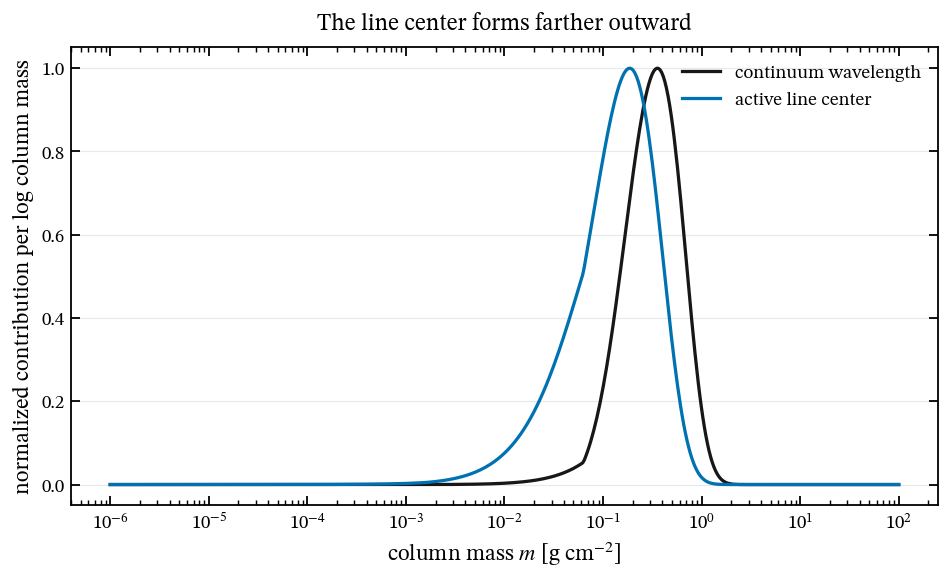

continuum contribution peak: 3.524e-01 g cm^-2
line-center contribution peak: 1.882e-01 g cm^-2


In [8]:
contribution = contribution_checkpoint()

figure, axes = single_panel()
axes.semilogx(
    contribution.column_mass,
    contribution.continuum_contribution,
    color=PAPER_COLORS["black"],
    label="continuum wavelength",
)
axes.semilogx(
    contribution.column_mass,
    contribution.line_contribution,
    color=PAPER_COLORS["blue"],
    label="active line center",
)
axes.set(
    xlabel=r"column mass $m$ [g cm$^{-2}$]",
    ylabel="normalized contribution per log column mass",
    title="The line center forms farther outward",
)
axes.legend()
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)

print(
    "continuum contribution peak:",
    f"{contribution.continuum_peak_column_mass:.3e} g cm^-2",
)
print(
    "line-center contribution peak:",
    f"{contribution.line_peak_column_mass:.3e} g cm^-2",
)


The selected line contribution peaks at smaller column mass—farther
outward—than the neighboring continuum. Neither curve is a thin
formation surface. Eddington–Barbier,
\(I_\nu(0,\mu)\approx S_\nu(\tau_\nu=\mu)\), is useful intuition for
a smooth nearly linear source, not the production algorithm.

> **Movement II — Scattering makes the source implicit.**
> A known source was enough for the formal solution. Scattering
> makes that source depend on the radiation field it creates.

## 9.7 Source iteration solves a static feedback

The complete source is

\[
S_\nu=(1-\alpha_\nu)S_{\nu,\mathrm{th}}+\alpha_\nu J_\nu.
\]

A **Lambda operator** is the linear mapping from a complete source
vector to its mean-intensity vector:
\(J_\nu=\Lambda[S_\nu]\). A **source iteration** repeatedly
reconciles the source with that radiation field. It updates
radiation while temperature, populations, and opacity remain fixed;
it is not an NLTE population solve.

<figure>
  <img src="assets/schematics/textbook/ch09-scattering-fixed-point-v1.png"
       alt="Original hand-sketched fixed-point loop in which a complete source undergoes formal transfer to produce mean intensity, which corrects the source, while the local thermal source enters once from outside.">
  <figcaption><strong>Scattering makes the source implicit.</strong>
  A trial source creates a mean intensity through formal transfer;
  the scattered part of that field then corrects the source.
  Repetition solves a static numerical fixed point, not a time
  evolution.</figcaption>
</figure>

## 9.8 One static 51-point grid makes the operator reusable

Every wavelength has its own physical \(\tau_\nu(m)\). The
synthesis operator instead lives on a common 51-point grid from
zero to twenty. The archive is static physical/numerical input, not
a golden answer. `TransferTables.from_npz(...)` loads only the
consumed fields onto the requested device and dtype and derives the
contiguous diagonal.


In [9]:
table_check = transfer_table_checkpoint()

print("synthesis archive:", SYNTHESIS_TRANSFER_TABLES_SHA256[:16], "...")
for field, shape in zip(
    table_check.synthesis_fields,
    table_check.synthesis_shapes,
):
    print(f"  {field:34s} {shape}")
print("dtype/device:", table_check.synthesis_dtype, table_check.synthesis_device)
print("atmosphere table dtypes:", table_check.atmosphere_dtypes)
print("shared grid exact:", table_check.shared_grid_exact)
print(
    "shared surface weights exact:",
    table_check.shared_surface_weights_exact,
)
print(
    "mean-operator differences:",
    table_check.mean_operator_differing_entries,
    "entries; max",
    f"{table_check.mean_operator_max_abs_difference:.1e}",
)


synthesis archive: 64f75de9af02697c ...
  transfer_optical_depth_grid        (51,)
  mean_intensity_operator            (51, 51)
  mean_intensity_diagonal            (51,)
  surface_eddington_flux_weights     (51,)
dtype/device: torch.float64 cpu
atmosphere table dtypes: ('float32', 'float32', 'float64', 'float32', 'float32')
shared grid exact: True
shared surface weights exact: True
mean-operator differences: 4 entries; max 1.0e-08


The synthesis and atmosphere grids and surface weights are
byte-identical, but four stored mean-operator entries differ by up
to \(10^{-8}\). Shared physics does not authorize averaging them or
inventing one universal table.

The exact synthesis remap uses `torch.searchsorted` independently
for every target depth. The first brackets use a line, supported
interiors blend two parabolas, and the deepest edge uses a backward
stencil. Curvature weights are detached because stencil selection
is discrete. Grid points above the first stored layer receive that
layer's source and scattering fraction explicitly.


In [10]:
remap = remap_checkpoint()

assert remap.exact_point_max_abs < 3.0e-15
assert remap.above_atmosphere_source_exact
assert remap.above_atmosphere_scattering_exact
assert np.all(np.isfinite(remap.thermal_source_grid))
assert np.all(
    (remap.scattering_fraction_grid >= 0.0)
    & (remap.scattering_fraction_grid <= 1.0)
)

print(
    "maximum error at exact source-grid points:",
    f"{remap.exact_point_max_abs:.3e}",
)
print(
    "targets above first stored layer:",
    remap.above_atmosphere_count,
)
print(
    "explicit surface replacement:",
    remap.above_atmosphere_source_exact
    and remap.above_atmosphere_scattering_exact,
)


maximum error at exact source-grid points: 2.220e-16
targets above first stored layer: 29
explicit surface replacement: True


## 9.9 The backward source correction is ordered

On the common grid, a Jacobi-style fixed point would use only the
previous complete source. The production correction instead walks
from depth index 50 back to 0:

\[
\Delta S_i=
\frac{\alpha_i(\Lambda S)_i
      +(1-\alpha_i)S_{\mathrm{th},i}-S_i}
     {1-\alpha_i\Lambda_{ii}}.
\]

A newly corrected deeper source immediately affects the next
shallower row. Wavelength rows are independent, but this backward
depth sweep is sequential.


In [11]:
hand = hand_sweep_checkpoint()

np.testing.assert_array_equal(hand.hand_source, hand.exact_source)
print("depth   thermal source   alpha   source after one sweep")
for depth, (thermal, alpha, source) in enumerate(
    zip(
        hand.thermal_source,
        hand.scattering_fraction,
        hand.exact_source,
    )
):
    print(f"{depth:5d}   {thermal:14.7f}   {alpha:5.2f}   {source:20.7f}")
print(
    "hand and exact fp32 update are bit-equal:",
    np.array_equal(hand.hand_source, hand.exact_source),
)


depth   thermal source   alpha   source after one sweep
    0        0.7008878    0.20              0.7008878
    1        0.8508264    0.45              0.8508264
    2        0.7994741    0.70              0.7994741
hand and exact fp32 update are bit-equal: True


The synthesis algorithm starts from the thermal source, casts the
operator, diagonal, scattering fraction, and evolving source to
float32 on every backend, floors the source at \(10^{-38}\), and
performs exactly eight sweeps. There is no convergence test in
this route. Eight is a validated policy, not a universal theorem.


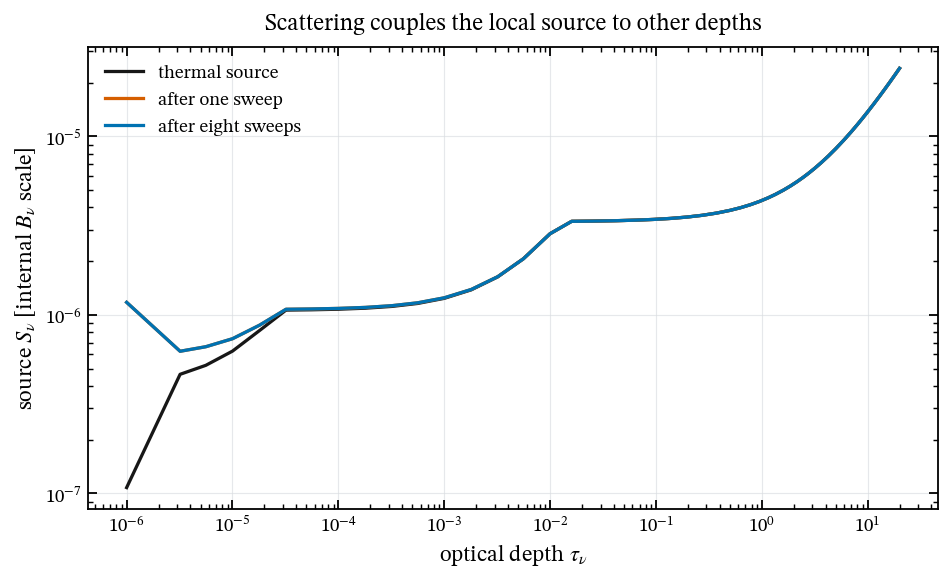

minimum source after sweeps 1..8: [6.2519598e-07 6.2519706e-07 6.2519706e-07 6.2519706e-07 6.2519706e-07
 6.2519706e-07 6.2519706e-07 6.2519706e-07]
largest relative change after sweep 1: 1.907e-06


In [12]:
sweep = source_sweep_checkpoint()

assert sweep.source_dtype == "torch.float32"
assert np.all(sweep.minimum_after_each_sweep > 0.0)
plot_tau = sweep.transfer_grid.copy()
plot_tau[0] = 1.0e-6
figure, axes = single_panel()
axes.semilogy(
    plot_tau,
    sweep.thermal_source,
    color=PAPER_COLORS["black"],
    label="thermal source",
)
axes.semilogy(
    plot_tau,
    sweep.one_sweep_source,
    color=PAPER_COLORS["orange"],
    label="after one sweep",
)
axes.semilogy(
    plot_tau,
    sweep.eight_sweep_source,
    color=PAPER_COLORS["blue"],
    label="after eight sweeps",
)
axes.set_xscale("log")
axes.set(
    xlabel=r"optical depth $\tau_\nu$",
    ylabel=r"source $S_\nu$ [internal $B_\nu$ scale]",
    title="Scattering couples the local source to other depths",
)
axes.legend()
add_quiet_grid(axes, axis="both")
plt.show()
plt.close(figure)
print("minimum source after sweeps 1..8:", sweep.minimum_after_each_sweep)
remaining = np.max(np.abs(
    sweep.eight_sweep_source / sweep.one_sweep_source - 1.0
))
print("largest relative change after sweep 1:", f"{remaining:.3e}")


The logarithmic horizontal axis places the exact
\(\tau_\nu=0\) surface point at \(10^{-6}\) only for display.
Scattering changes the source most strongly near that boundary,
where radiation can escape; deeper layers remain close to their
local thermal source. The orange and blue curves nearly coincide
because this row's largest remaining change after the first sweep
is only the value printed above; the fixed eight sweeps preserve
the exact production policy even when convergence is already rapid.

## 9.10 Surface \(H_\nu\) is a moment, not yet public \(F_\lambda\)

The converged source row meets
`surface_eddington_flux_weights` in a matrix product. The source
iteration is always float32; this final product is float64 on
CPU/CUDA and float32 on MPS. Wavelength is the batch axis. Nothing
crosses to the host inside the transfer solve.


In [13]:
window = prepared_window_checkpoint()
wavelength_index = int(np.argmin(window.normalized_flux))
tables = synthesis_transfer_tables()
column_mass = torch.as_tensor(window.column_mass, dtype=torch.float64)
source_rows = torch.as_tensor(window.planck_source.T, dtype=torch.float64)
continuum_rows = torch.as_tensor(
    window.continuum_absorption.T,
    dtype=torch.float64,
)
scattering_rows = torch.as_tensor(
    window.continuum_scattering.T,
    dtype=torch.float64,
)
line_rows = torch.as_tensor(
    window.line_mass_absorption_coefficient.T,
    dtype=torch.float64,
)
batch_h = _solve_flux_rows(
    continuum_rows, source_rows, line_rows, source_rows,
    scattering_rows, torch.zeros_like(line_rows), column_mass,
    tables, assert_no_saturated_core=False,
)
scalar_h = _solve_flux_rows(
    continuum_rows[wavelength_index:wavelength_index + 1],
    source_rows[wavelength_index:wavelength_index + 1],
    line_rows[wavelength_index:wavelength_index + 1],
    source_rows[wavelength_index:wavelength_index + 1],
    scattering_rows[wavelength_index:wavelength_index + 1],
    torch.zeros_like(line_rows[wavelength_index:wavelength_index + 1]),
    column_mass, tables, assert_no_saturated_core=False,
)
torch.testing.assert_close(scalar_h[0], batch_h[wavelength_index])
print("ordered axis: depth; batch axis: wavelength")
print("surface product dtype:", batch_h.dtype)
print("scalar/batch |delta H_nu|:", float(abs(scalar_h[0] - batch_h[wavelength_index])))


ordered axis: depth; batch axis: wavelength
surface product dtype: torch.float64
scalar/batch |delta H_nu|: 1.0587911840678754e-22


/Users/ysting/stellar-spectroscopy-from-scratch-gpu/src/payne_zero_synthesis/radiative_transfer.py:299: UserWarning: torch.searchsorted(): boundary tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous boundary tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:40.)
  bracket_ordinal = torch.searchsorted(optical_depth, transfer_depths, right=True) + 1


## 9.11 A saturated surface needs a diffusion route

The fixed grid ends at \(\tau_\nu=20\). A row is saturated only
when its *first* physical layer satisfies
`optical_depth[:, 0] > 20`; equality remains on the fixed-grid
route. Direct `_solve_flux_rows(...)` calls are strict by default
and raise. The synthesis pipeline explicitly permits a fallback.

The fallback begins from the diffusion relation

\[
H_\nu\simeq\frac13\frac{dS_\nu}{d\tau_\nu},
\]

uses a slope-limited derivative and scattering curvature
correction, permits at most 51 updates, and stops a row when its
summed relative change is below \(10^{-5}\). The threshold plot
below displays a numerical route boundary, not a physical
discontinuity in a spectral line.


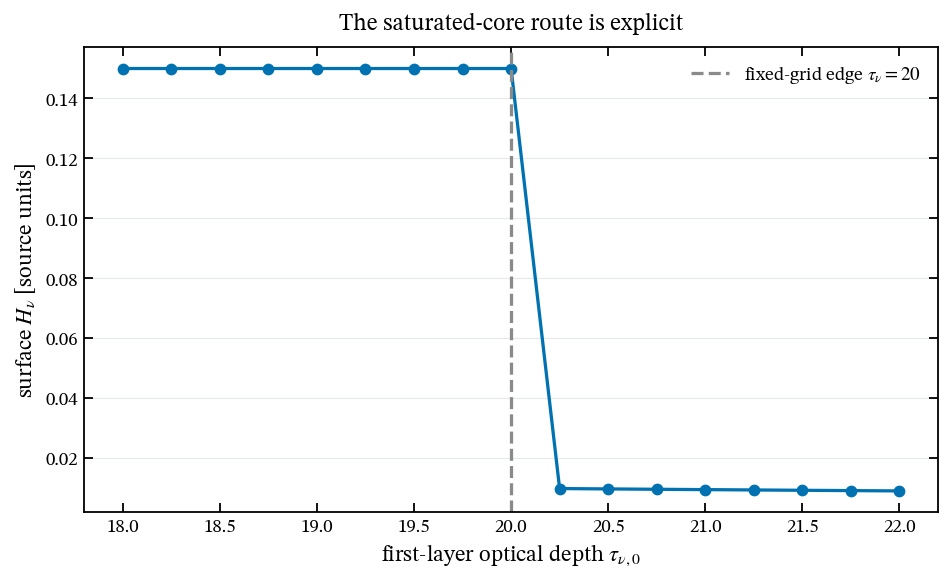

strict route raised: True
fallback rows: 8


In [14]:
saturated = saturated_route_checkpoint()

assert saturated.strict_failure_seen
assert np.all(np.isfinite(saturated.eddington_flux_per_frequency))
assert np.all(saturated.eddington_flux_per_frequency > 0.0)
figure, axes = single_panel()
axes.plot(
    saturated.first_layer_optical_depth,
    saturated.eddington_flux_per_frequency,
    color=PAPER_COLORS["blue"],
    marker="o",
)
axes.axvline(
    saturated.threshold,
    color=PAPER_COLORS["grey"],
    linestyle="--",
    label=r"fixed-grid edge $\tau_\nu=20$",
)
axes.set(
    xlabel=r"first-layer optical depth $\tau_{\nu,0}$",
    ylabel=r"surface $H_\nu$ [source units]",
    title="The saturated-core route is explicit",
)
axes.legend()
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)
print("strict route raised:", saturated.strict_failure_seen)
print("fallback rows:", int(np.count_nonzero(saturated.saturated_mask)))


> **Movement III — Two physical solves make a normalization.**
> Total and continuum are not one solve followed by a fitted
> baseline; they are two branches through the same atmosphere.

<figure>
  <img src="assets/schematics/textbook/ch09-total-continuum-stack-v1.png"
       alt="Original hand-sketched two-lane diagram in which one atmosphere feeds total transfer with continuum and line opacity and continuum transfer with line terms set to zero, with the two resulting fluxes meeting only in their normalized-flux ratio.">
  <figcaption><strong>Two physical solves, one ratio.</strong>
  Total and continuum flux use the same atmosphere and transfer
  physics. The continuum branch removes line terms; only the two
  emergent fluxes meet when normalized flux is formed.</figcaption>
</figure>

## 9.12 Total and continuum rows share one launch

`solve_spectrum(...)` transposes depth-major inputs to contiguous
`(W,D)` rows. It stacks total rows above continuum rows and calls
the transfer operator once. The continuum half zeros both line
absorption and line scattering while keeping continuum absorption,
continuum scattering, Planck source, and column mass unchanged.


In [15]:
window = prepared_window_checkpoint()

assert window.stacked_max_abs_difference < 1.0e-12
print("input axes:    (depth, wavelength)")
print("transfer axes: (wavelength, depth)")
print("returned axes: (wavelength,)")
print(
    "stacked versus two independent calls, max |delta H_nu|:",
    f"{window.stacked_max_abs_difference:.3e}",
)
print(
    "total H_nu range:",
    f"{window.eddington_flux_total_per_frequency.min():.3e}",
    "to",
    f"{window.eddington_flux_total_per_frequency.max():.3e}",
)
print(
    "continuum H_nu range:",
    f"{window.eddington_flux_continuum_per_frequency.min():.3e}",
    "to",
    f"{window.eddington_flux_continuum_per_frequency.max():.3e}",
)


input axes:    (depth, wavelength)
transfer axes: (wavelength, depth)
returned axes: (wavelength,)
stacked versus two independent calls, max |delta H_nu|: 5.366e-15
total H_nu range: 7.858e-07 to 9.694e-07
continuum H_nu range: 9.980e-07 to 9.994e-07


## 9.13 Zero line opacity gives normalized flux one

At a common wavelength,

\[
f_{\rm norm}=
  \frac{H_{\nu,\rm total}}{H_{\nu,\rm continuum}}.
\]

If line opacity is zero, the two physical problems are identical.
Their ratio should therefore be one within the declared batched
float32-source/float64-surface policy.


In [16]:
zero_line_error = np.max(
    np.abs(window.zero_line_normalized_flux - 1.0)
)
assert zero_line_error < 1.0e-9

print(
    "maximum |H_total / H_continuum - 1| with zero line opacity:",
    f"{zero_line_error:.3e}",
)
print(
    "prediction confirmed:",
    bool(np.allclose(
        window.zero_line_normalized_flux,
        1.0,
        rtol=1.0e-9,
        atol=1.0e-12,
    )),
)


maximum |H_total / H_continuum - 1| with zero line opacity: 3.369e-11
prediction confirmed: True


The ratio is not an observed-spectrum continuum fit, polynomial
baseline, or instrument correction. It divides two transfer
calculations. We now restore the Chapter 5–8 atomic and molecular
opacity window.


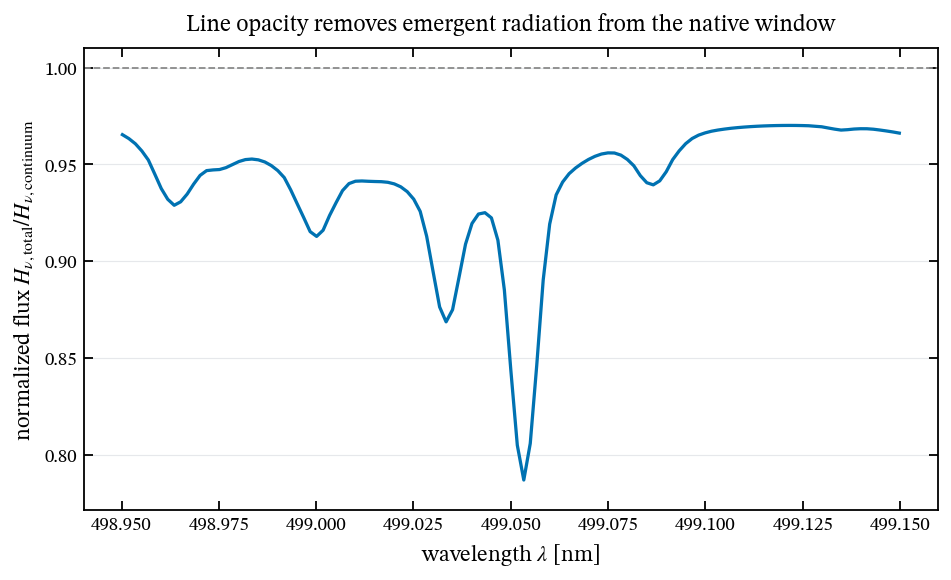

deepest sample: 499.053338 nm, normalized flux 0.786814


In [17]:
figure, axes = single_panel()
axes.plot(
    window.wavelength_nm,
    window.normalized_flux,
    color=PAPER_COLORS["blue"],
)
axes.axhline(
    1.0,
    color=PAPER_COLORS["grey"],
    linestyle="--",
    linewidth=1.0,
)
axes.set(
    xlabel=r"wavelength $\lambda$ [nm]",
    ylabel=r"normalized flux $H_{\nu,\mathrm{total}}/H_{\nu,\mathrm{continuum}}$",
    title="Line opacity removes emergent radiation from the native window",
)
axes.set_ylim(
    min(0.98, 0.98 * float(window.normalized_flux.min())),
    1.01,
)
add_quiet_grid(axes, axis="y")
plt.show()
plt.close(figure)

minimum_index = int(np.argmin(window.normalized_flux))
print(
    "deepest sample:",
    f"{window.wavelength_nm[minimum_index]:.6f} nm,",
    f"normalized flux {window.normalized_flux[minimum_index]:.6f}",
)


## 9.14 How a stronger line becomes a wider one

The dip we just plotted invites an obvious question: if we doubled
the number of absorbers, how much darker would it get? The answer is
not "twice", and the reason is worth following, because it governs
what a spectrum can and cannot tell us about a star.

First we need one number for a line rather than a whole profile. The
**equivalent width** is the width of a completely black rectangle
that removes the same total flux,

\[
W_\lambda=\int\left(1-\frac{F_\lambda}{F_{\lambda,c}}\right)d\lambda .
\]

It measures area removed, so it survives any smearing that conserves
area — an instrumental profile changes the shape of a line but not
its equivalent width. That is what makes it the natural currency for
line strength.

To see how \(W_\lambda\) responds to strength, take a controlled
limit in the same spirit as Chapter 1's grey atmosphere. Put a cool
absorbing layer in front of a continuum source, so the emergent
normalized flux is simply attenuated,

\[
\frac{F}{F_c}=e^{-\tau(u)},
\qquad
\tau(u)=\tau_0\,\frac{H(a,u)}{H(a,0)} ,
\]

with \(\tau_0\) the line-centre optical depth and \(u\) the Doppler
offset of §6.7. In Doppler-width units the equivalent width is then

\[
\frac{W}{\Delta\lambda_D}
=\int_{-\infty}^{\infty}
  \left(1-e^{-\tau(u)}\right)du .
\]

Three regimes fall out of that single integral, and they are visible
in the calculation below.

**Weak lines grow linearly.** When \(\tau_0\ll1\),
\(1-e^{-\tau}\approx\tau\), so \(W\propto\tau_0\). Every added
absorber removes its own share of flux, and the line faithfully
reports how many absorbers there are.

**Saturated lines barely grow at all.** Once \(\tau_0\gtrsim1\) the
core reaches \(F/F_c\approx0\) and can get no darker. Additional
absorbers only push the *edges* of the black core outward, and
because the Gaussian core falls off as \(e^{-u^2}\), the black region
widens only as \(\sqrt{\ln\tau_0}\). This is the flat part of the
curve, and it is the reason a strong line is a poor abundance
indicator: the spectrum has stopped counting.

**Damping wings restore growth.** Far enough out, the Lorentzian
wings of §6.6 dominate the Gaussian, falling only as \(u^{-2}\).
Their contribution to the integral scales as \(\sqrt{a\tau_0}\), so
once the wings become opaque the line grows as \(\sqrt{\tau_0}\)
again — more slowly than linear, but no longer stalled.


equivalent width of the synthesized window: 1.206401e-02 nm


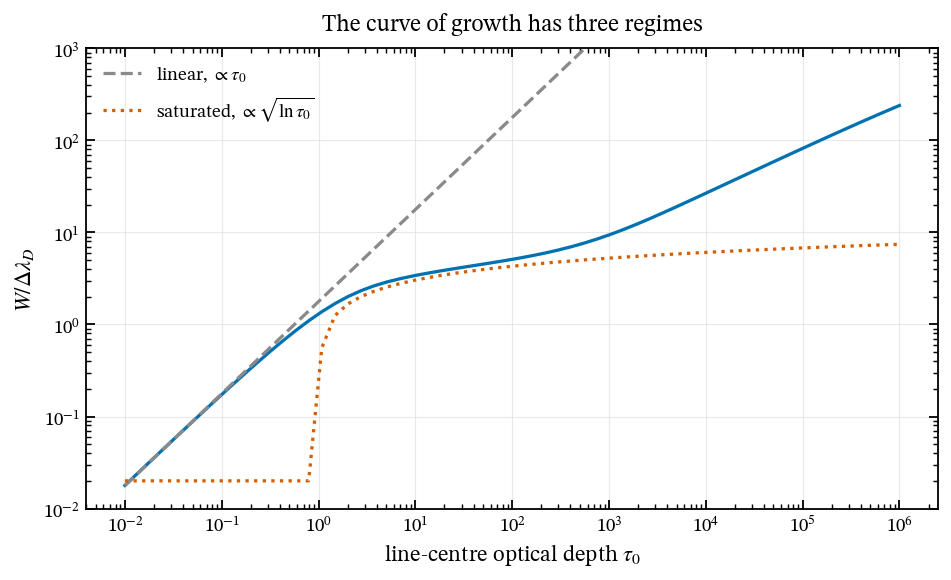

In [18]:
absorbed = 1.0 - window.normalized_flux
measured = float(np.sum(
    0.5 * (absorbed[1:] + absorbed[:-1])
    * np.diff(window.wavelength_nm)
))
print(f"equivalent width of the synthesized window: {measured:.6e} nm")


# The profile shape does not depend on tau_0, so evaluate it once.
# The reference Voigt is a convolution per sample, so the grid is
# dense only through the core and logarithmic across the wings.
positive = np.concatenate((
    np.linspace(0.0, 6.0, 1201),
    np.logspace(np.log10(6.0), np.log10(400.0), 1200)[1:],
))
offsets = np.concatenate((-positive[:0:-1], positive))
shape = continuous_voigt_h(offsets, 0.01)
shape = shape / shape.max()

def equivalent_width(values, grid):
    return float(np.sum(
        0.5 * (values[1:] + values[:-1]) * np.diff(grid)
    ))

depths = np.logspace(-2.0, 6.0, 60)
widths = np.asarray([
    equivalent_width(1.0 - np.exp(-depth * shape), offsets)
    for depth in depths
])

figure, axes = single_panel()
axes.loglog(depths, widths, color=PAPER_COLORS["blue"])
axes.loglog(depths, np.sqrt(np.pi) * depths, linestyle="--",
            color=PAPER_COLORS["grey"], label=r"linear, $\propto\tau_0$")
axes.loglog(depths, 2.0 * np.sqrt(np.log(np.maximum(depths, 1.0001))),
            linestyle=":", color=PAPER_COLORS["orange"],
            label=r"saturated, $\propto\sqrt{\ln\tau_0}$")
axes.set(
    xlabel=r"line-centre optical depth $\tau_0$",
    ylabel=r"$W/\Delta\lambda_D$",
    title="The curve of growth has three regimes",
)
axes.set_ylim(1.0e-2, 1.0e3)
add_quiet_grid(axes)
axes.legend()
plt.show()
plt.close(figure)


The computed curve tracks the linear asymptote while the line is
weak, flattens onto the logarithmic branch through the saturated
middle, and steepens again once the damping wings take over. The flat
section spans several decades in \(\tau_0\) for only a factor of a
few in \(W\) — which is exactly why abundance work prefers weak lines,
and why a synthesis code must model the whole profile rather than
fit a single depth.

Nothing here changes the calculation the rest of the book performs:
our synthesis always integrates the full profile through a real
atmosphere, which reproduces all three regimes automatically. The
controlled slab is a way to understand the answer, not a shortcut
used to obtain it.

## 9.15 Convert \(H_\nu\) to public \(F_\lambda\) per nanometre

`eddington_flux_total_per_frequency` is not yet
`Spectrum.flux_total`. First,

\[
F_\nu=4\pi H_\nu.
\]

Then use the absolute frequency-to-wavelength Jacobian, with
\(c_{\rm nm\,s^{-1}}\) expressed in nm s\(^{-1}\):

\[
\left|\frac{d\nu}{d\lambda_{\rm nm}}\right|
  =\frac{c_{\rm nm\,s^{-1}}}{\lambda_{\rm nm}^2},
\qquad
F_\lambda\ {\rm per\ nm}
  =4\pi H_\nu
   \frac{c_{\rm nm\,s^{-1}}}{\lambda_{\rm nm}^2}.
\]

The compact public-helper check below crosses to NumPy only for
these three diagnostics. In complete synthesis, the spectral
arrays remain on the selected device until the final result is
constructed.


In [19]:
conversion = flux_conversion_checkpoint()

np.testing.assert_allclose(
    conversion.flux_per_wavelength_nm,
    conversion.helper_flux_per_wavelength_nm,
    rtol=0.0,
    atol=0.0,
)
np.testing.assert_allclose(
    conversion.normalized_before,
    conversion.normalized_after,
    rtol=2.0e-16,
    atol=0.0,
)
inverse_square_check = (
    conversion.flux_per_wavelength_nm
    / conversion.flux_per_frequency
    * np.square(conversion.wavelength_nm)
)
print("wavelength [nm]   H_nu          F_nu          F_lambda per nm")
for values in zip(
    conversion.wavelength_nm,
    conversion.eddington_flux_per_frequency,
    conversion.flux_per_frequency,
    conversion.flux_per_wavelength_nm,
):
    print(f"{values[0]:14.6f}   {values[1]:.3e}   {values[2]:.3e}   {values[3]:.3e}")
print("Jacobian invariant:", inverse_square_check)
print(
    "ratio survives conversion:",
    np.allclose(
        conversion.normalized_before,
        conversion.normalized_after,
    ),
)


wavelength [nm]   H_nu          F_nu          F_lambda per nm
    498.966843   9.329e-07   1.172e-05   1.412e+07
    499.050011   8.425e-07   1.059e-05   1.274e+07
    499.133192   9.676e-07   1.216e-05   1.463e+07
Jacobian invariant: [2.99792458e+17 2.99792458e+17 2.99792458e+17]
ratio survives conversion: True


> **Movement IV — The same physics serves a different atmosphere
> product.**

<figure>
  <img src="assets/schematics/textbook/ch09-two-transfer-lanes-v1.png"
       alt="Original hand-sketched comparison of a Torch wavelength-batched synthesis transfer lane returning surface total and continuum Eddington fluxes and a Numba frequency-chunked atmosphere lane returning depth-dependent moments with private accumulators and fixed-order reduction; depth remains ordered in both.">
  <figcaption><strong>Shared physics, distinct executable boundaries.</strong>
  Synthesis batches wavelengths on the selected Torch device and
  returns surface moments. Atmosphere transfer parallelizes private
  frequency chunks on the CPU, preserves each depth recurrence,
  and returns depth-dependent moments for later structure
  corrections.</figcaption>
</figure>

## 9.16 The atmosphere lane retains monochromatic depth structure

The exact atmosphere table loads surface-\(H_\nu\) weights,
second-moment weights, and the two `(51,51)` moment operators as
float32, while its transfer grid remains float64. Its fixed-grid
source iteration may stop early, but uses at most 51 sweeps and a
\(10^{-5}\) relative-correction criterion. Denominators,
relative-error scales, and updated sources use a separate
\(10^{-37}\) guard/floor.

Layers deeper than the fixed grid continue by diffusion:
\(H_\nu=(1/3)dS_\nu/d\tau_\nu\) and
\(J_\nu-S_\nu=dH_\nu/d\tau_\nu\). Invalid nonpositive deep sources
or fluxes trigger a Planck reset before continuation. This is
related to, but not byte-identical with, the synthesis saturated
fallback.

The atmosphere line slab arrives as gross float32 opacity. The
transfer runner converts it to float64 and multiplies the
stimulated-emission factor exactly once. The cell below exposes
one deep-controlled frequency, then compares serial and two-chunk
accumulator routes. The frequency-integrated accumulators are
named only as the Chapter 12 handoff; their physical use remains
there.


In [20]:
atmosphere = atmosphere_moment_checkpoint(deep=True)
parallel = atmosphere_parallel_checkpoint()

expected_line = (
    atmosphere.gross_line_mass_absorption_coefficient.astype(np.float64)
    * atmosphere.stimulated
)
np.testing.assert_array_equal(
    atmosphere.stimulated_line_mass_absorption_coefficient,
    expected_line,
)
assert np.all(np.diff(atmosphere.optical_depth) >= 0.0)
assert np.all(np.isfinite(atmosphere.mean_intensity))
assert np.all(np.isfinite(atmosphere.eddington_flux))
assert parallel.fixed_policy_repeatable

print("single-frequency physical-depth outputs")
print("  optical_depth:", atmosphere.optical_depth.shape, "float64")
print("  source:", atmosphere.source.shape, "float64")
print("  mean_intensity:", atmosphere.mean_intensity.shape, "float64")
print("  eddington_flux:", atmosphere.eddington_flux.shape, "float64")
print("  surface_second_moment:", f"{atmosphere.surface_second_moment:.6e}")
print("  fixed-grid mapped layers:", atmosphere.mapped_layer_count)
print("  gross fp32 line opacity stimulated exactly once: True")
print()
print("serial versus two chunks")
print("  worst output:", parallel.worst_output_name)
print("  worst absolute difference:", f"{parallel.worst_absolute_difference:.3e}")
print("  worst relative difference:", f"{parallel.worst_relative_difference:.3e}")
print("  repeated two-chunk result identical:", parallel.fixed_policy_repeatable)


single-frequency physical-depth outputs
  optical_depth: (12,) float64
  source: (12,) float64
  mean_intensity: (12,) float64
  eddington_flux: (12,) float64
  surface_second_moment: 2.862040e-01
  fixed-grid mapped layers: 10
  gross fp32 line opacity stimulated exactly once: True

serial versus two chunks
  worst output: rosseland_accumulator
  worst absolute difference: 0.000e+00
  worst relative difference: 0.000e+00
  repeated two-chunk result identical: True


The controlled mini-batch agrees exactly for this fixed grouping.
That is not a promise of cross-thread bit identity: changing chunk
count changes the final floating-point grouping. `prange` belongs
only around independent contiguous frequency chunks with private
accumulators. One frequency's optical-depth integral, backward
source sweep, and diffusion continuation remain serial.

The atmosphere outputs now available at one frequency are
`optical_depth_out`, `source_out`, `eddington_flux_out`,
`mean_intensity_out`, `mean_intensity_minus_source_out`,
`total_opacity_out`, `scattering_fraction_out`, and
`surface_second_moment`. The later atmosphere-iteration stage will
integrate them into Rosseland, pressure, acceleration, heating,
and temperature-correction quantities; doing so here would turn a
transfer chapter into an atmosphere-iteration chapter.

## 9.17 Chapter summary

1. Absorption, scattering, and thermal emissivity determine
   extinction, `scattering_fraction`, and `thermal_source`; equal
   extinction alone does not determine escaping radiation.
2. \(d\tau_\nu=\chi_\nu\,dm\) orders physical layers by the
   wavelength-specific difficulty of escape.
3. The formal solution maps a known source into directional
   intensity; angular moments \(J_\nu\), \(H_\nu\), and \(K_\nu\)
   summarize brightness and flow, with \(F_\nu=4\pi H_\nu\).
4. Scattering makes \(S_\nu\) depend on \(J_\nu\). A fixed
   51-point operator and deepest-to-surface source iteration solve
   that static feedback.
5. Synthesis solves total and continuum \(H_\nu\) together, forms
   their physical ratio, and has an explicit diffusion fallback
   when the first stored layer lies beyond \(\tau_\nu=20\).
6. Public flux per wavelength is
   \(F_\lambda=4\pi H_\nu
   c_{\rm nm\,s^{-1}}/\lambda_{\rm nm}^2\), in
   erg s\(^{-1}\) cm\(^{-2}\) nm\(^{-1}\).
7. Atmosphere transfer uses the same physics but a separate table,
   convergence policy, diffusion continuation, and CPU
   frequency-chunk product returning depth-dependent moments.

The checked transfer boundary is now

```text
prepared depth-wavelength opacity + one structured atmosphere
    -> device-resident total H_nu
    -> device-resident continuum H_nu
    -> device-resident normalized_flux
    -> checked public F_lambda-per-nm conversion semantics
```

### Next: keep the whole spectrum on the right device

The transfer operator can now turn prepared opacity slabs into a
physical native spectrum. A broad calculation must still assemble
those slabs in the right order, reuse everything that does not
depend on the star, bound memory, and cross to the host only once.
[Chapter 10 composes that complete CUDA/MPS/CPU synthesis pipeline
without re-deriving the transfer physics.](/reader.html?ch=10)
